In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os
import matplotlib.ticker as ticker
from adjustText import adjust_text
import copy
import statistics
import pandas as pd

In [2]:
file_path = "C:\\Users\\zyx\\Desktop\\data\\CO_and_HCO\\source.vsys.dat"
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df = pd.read_csv(
    file_path,
    sep='\s+',          # 按空格/制表符分隔
    comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

print(df)   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查

   source, field,        ra,       dec,       Vsys,  Vsys_sigma
0     Ll01   Ll01  81.505174 -67.503328  287.328125    0.983483
1     Ll02   Ll02  73.534500 -66.775389  274.113342    1.343082
2     Ll03   Ll03  84.478441 -69.576586  265.006836    0.913653
3     Ll04   Ll04  75.983875 -67.344111  269.604950    2.035654
4   Ll04_2   Ll04  75.982767 -67.345826  268.652863    1.179893
..     ...    ...        ...        ...         ...         ...
66     S07    S07  13.514352 -73.327366  163.216629    1.475220
67     S08    S08  12.257295 -73.186037  146.751221    1.218433
68     S09    S09  11.235079 -73.169770  132.257156    2.265169
69     S10    S10  16.280342 -71.995208  189.761490    1.967455
70   S10_2    S10  16.274230 -71.995216  190.884918    1.150420

[71 rows x 6 columns]


In [3]:
sou=df["source,"].tolist()
V=df["Vsys,"].tolist()
print(sou)
print(V)
print(type(sou))
print(type(V))

['Ll01', 'Ll02', 'Ll03', 'Ll04', 'Ll04_2', 'Ll05', 'Ll06', 'Ll06_2', 'Ll06_3', 'Ll07', 'Ll07_2', 'Ll08', 'Ll09', 'Ll09_2', 'Ll09_3', 'Ll09_4', 'Ll09_5', 'Ll10', 'Ll10_2', 'Lm01', 'Lm02', 'Lm02_2', 'Lm02_3', 'Lm03', 'Lm04', 'Lm04_2', 'Lm04_3', 'Lm05', 'Lm05_2', 'Lm05_3', 'Lm06', 'Lm06_2', 'Lm06_3', 'Lm07', 'Lm07_2', 'Lm07_3', 'Lm08', 'Lm09', 'Lm10', 'Lh01', 'Lh01_2', 'Lh01_3', 'Lh02', 'Lh02_2', 'Lh02_3', 'Lh03', 'Lh04', 'Lh05', 'Lh05_2', 'Lh05_3', 'Lh05_4', 'Lh06', 'Lh07', 'Lh08', 'Lh08_2', 'Lh08_3', 'Lh08_4', 'Lh09', 'Lh10', 'S01', 'S01_2', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S10_2']
[287.328125, 274.1133423, 265.0068359, 269.60495, 268.6528625, 274.9273682, 231.8370972, 232.4548035, 235.1858368, 267.088623, 266.247467, 235.3066406, 283.1570435, 282.2198181, 285.8900146, 279.8934326, 281.043335, 249.9293213, 249.9293213, 276.4645691, 230.7684784, 230.9107971, 229.9667053, 296.7356262, 283.2704773, 282.0755615, 284.4465637, 236.2545319, 237.4716644, 233.84242

In [4]:
def open_file():
    path='C:\\Users\\zyx\\Desktop\\data\\spw1'  #设置存储路径
    files= os.listdir(path) #得到文件夹下的所有文件名称
    name_list=source_name(files) # 得到每个源的名字
    data=[]  # 建立空列表储存数据
    data_i=0 # 记录是第几个文件

    for file in files:  #按照顺序在 files 里面进行每一个文件的 数据名称 循环读取
        position = path+"\\"+file   # 打开第一个文件
        data.append([])
        with open(position, 'r') as f:
            line_num=0
            for line in f:
                if line_num>0:
                    data[data_i].append(line.strip().split())
                line_num+=1
        data_i+=1
    return data,name_list

In [5]:
def source_name(name):
    name_list=[]
    for i in range(len(name)):
        part=name[i].split(".")
        name_list.append(part[1])
    return name_list

In [6]:
def data_to_xy(data):   # 输入某一个文件的数据，转换成xy
    data_x=[]
    data_y=[]
    for i in range(len(data)):
        data_x.append(float(data[i][0]))
        data_y.append(float(data[i][1]))
    return data_x,data_y

In [7]:
def paint(x,y):    # 把光谱画出来
    plt.plot(x,y)
    plt.xlabel("frequency (GHz)")
    plt.ylabel("flux (Jy/beam)")
    #plt.autoscale(enable=True, axis='y', tight=True)
    plt.ticklabel_format(useOffset=False, style='plain')
    plt.show()

In [8]:
def noise_sigma(raw_data,a):
    noise=raw_data[a:a+200]    #宽度为0.2Hz的噪声区间
    noise_x,noise_y=data_to_xy(noise)
    #paint(noise_x,noise_y)
    return noise_y

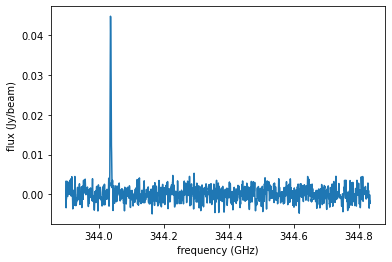

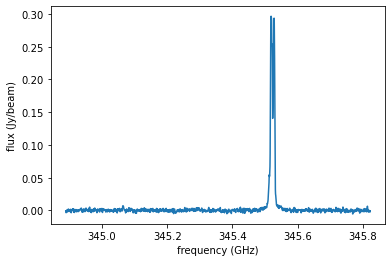

200


In [9]:
data,name_list=open_file()
for i in range(2):
    x,y=data_to_xy(data[i])
#     print(len(x))
#     x1,y1=hebin(x,y)
    paint(x,y)
#     print(len(x1))
print(len(data))

In [10]:
# 计算每一条谱线噪声的σ
noise_list=[]
for i in range(len(data)):
    noise_y=noise_sigma(data[i],0)
    noise_level=np.std(noise_y)
    noise_list.append(noise_level)
# print(noise_list)

In [11]:
# 去掉3σ外的数据（把噪声3σ下的删掉）（没有合并时）
def remove_3sigma3(list1,list2,noise):
    list3=copy.deepcopy(list2)
#     a=max(list2)
#     n_a=list2.index(a)
    # 检测峰及其突出度
    peaks, properties = find_peaks(list3, prominence=0.2)
    print(peaks)
    left_peak=0
    right_peak=0
    if len(peaks) < 2:
        left_peak=list2.index(max(list2))
        right_peak=list2.index(max(list2))
        print("只有一个峰:",len(peaks))
    else:
        # 根据突出度选择前两个主峰
        prominences = properties['prominences']
        peak_indices = sorted(zip(prominences, peaks), key=lambda x: -x[0])[:2]
        selected_peaks = sorted([pi[1] for pi in peak_indices])  # 按位置排序
        left_peak, right_peak = selected_peaks
        print("有两个峰")
        
# 从最大值开始往左边找
    for i in range(left_peak-1,-1,-1):
        if list3[i]<noise*3 and list3[i-1]<noise*3 and list3[i-2]<noise*3:
            print("去除噪声（左边）")
            for j in range(i):
                list3[j]=0
            break
# 从最大值开始往右边找
    for i in range( right_peak,len(list3)):
        if list3[i]<noise*3 and list3[i+1]<noise*3 and list3[i+2]<noise*3:
            print("去除噪声（右边）")
            for j in range(i,len(list3)):
                list3[j]=0
            break
    print(left_peak, right_peak)
    return list3

In [12]:
# 归一化（用HCO+的数据归一化）
def guiyihua(list5,flux_HCO):
    list6=[]
    for i in range(len(list5)):
        list6.append(list5[i]/flux_HCO)
        
    return list6

In [13]:
def find_peak2(x,y):
    m=max(y)
    index_m=y.index(m)
    return m,index_m

In [14]:
# 放大谱线
def enlarge(x,y,noise):
    list_x=[]
    list_y=[]
    peak_list=find_peaks(y,height=noise*10,distance=70)
#     print(peak_list)
#     print(peak_list[0])
    if len(peak_list[0])!=0:
        for item in peak_list[0]:
            data_x=x[item-80:item+80]
            data_y=y[item-80:item+80]
            list_x.append(data_x)
            list_y.append(data_y)
    return list_x,list_y

In [15]:
# 找到每个源的视向速度
def Vsys(name,source,V):
    V_rest_source=[]
    for i in range(len(name)):
        for j in range (len(source)):
            if name[i]==source[j]:
                V_rest_source.append(V[j])
                break
    return V_rest_source

In [16]:
# x_freq_1=[]
# y_flux_1=[]

# for i in range(len(data)):
#     x,y=data_to_xy(data[i])
# #     paint(x,y)
# #     print(noise_list[i])
#     peak_x,peak_y=enlarge(x,y,noise_list[i])
#     x_freq_1.append(peak_x)
#     y_flux_1.append(peak_y)
# print(len(x_freq_1))   # [[[x],[y]],[[i],[j]]] 最里层：放大后的峰值  中间层：某一个文件  最外层：后续放入分类的数据
# print(len(y_flux_1))
# x_freq_2 = sum(x_freq_1,[])   # [[x],[y],[i],[j]] 最里层：放大后的峰值  最外层：后续放入分类的数据
# y_flux_2 = sum(y_flux_1,[])
# print(len(x_freq_2))
# print(len(y_flux_2))
# print(len(y_flux_2[0]))

In [17]:
def duiqi_v(list_x,list_y,delta_x,x_start,x_finish):
#     delta_x=0.4262   # 频率步长
#     x_start=-30 
#     x_finish=30
    num=int((x_finish-x_start)/delta_x)+1  # 对齐之后数据长度
    y_flux=[]   # 对齐横坐标之后，只需要记录纵坐标。这是纵坐标。
    find_x=[]
    find_y=[]
    find_x=copy.deepcopy(list_x)
    find_y=copy.deepcopy(list_y)

    for i in range(num):
        a=x_start+i*delta_x
        b=x_start+(i+1)*delta_x

    # 找原横坐标对应区间(比如新x轴在【-26.4，-26】区间内的数据，就要找到原来x轴位于该区间的数据)
        if len(find_x)>=3:        # 原来x轴的数据还剩下3个以上
            data1_x=find_x[0]
            data2_x=find_x[1]
            data3_x=find_x[2]
            #print(data1_x)
            if data1_x>=a and data1_x<=b and data2_x>=b:
                y_flux.append(find_y[0])
                find_x.remove(data1_x)   # 把已经找到的数据删掉
                find_y.remove(find_y[0])
                #print("进入了第一种情况")
                continue
            elif data1_x>b:
                y_flux.append(0)
#                 print("有0")
#                 print(n)
#                 print(data1_x,data2_x,data3_x)
#                 print(a,b)
                continue
            elif data1_x>=a and data2_x<=b and data3_x>b:
                y_flux.append((find_y[0]+find_y[1])/2)
                find_x.remove(data1_x)
                find_x.remove(data2_x)
                find_y.remove(find_y[0])
                find_y.remove(find_y[0])
                #print("进入了第三种情况")
                continue

        elif len(find_x)==2:         # 原来x轴的数据还剩下2个
            #print("还有2个数据！")
            data1_x=find_x[0]
            data2_x=find_x[1]
            if data1_x>=a and data1_x<=b and data2_x>=b:
                y_flux.append(find_y[0])
                find_x.remove(data1_x)   # 把已经找到的数据删掉
                find_y.remove(find_y[0])
                #print("进入了第一种情况")
                continue
            elif data1_x>b:
                y_flux.append(0)

                continue
            elif data1_x>=a and data2_x<=b:
                y_flux.append((find_y[0]+find_y[1])/2)
                find_x.remove(data1_x)
                find_x.remove(data2_x)
                find_y.remove(find_y[0])
                find_y.remove(find_y[0])
                #print("进入了第三种情况")
                continue

        elif len(find_x)==1:       # 原来x轴的数据还剩下1个
            #print("还有1个数据！")
            y_flux.append(find_y[0])
            find_x.remove(find_x[0])   # 把已经找到的数据删掉
            find_y.remove(find_y[0])
            continue

        elif len(find_x)==0:
            #print("没有数据了！")
            y_flux.append(0)
        

    #print(y_flux)
    #plt.plot(y_flux)
    return y_flux

In [18]:
V_rest_source=Vsys(name_list,sou,V)
print(len(V_rest_source))
print(len(data))

200
200


In [19]:
lll=[[] for _ in range(40)]
print(lll)
aaa=[1,2,3]
bbb=[4,5,6]
lll[0].append(aaa)
lll[0].append(bbb)
print(lll)
lll[0]=np.concatenate(lll[0]).tolist()
print(lll)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]
[[[1, 2, 3], [4, 5, 6]], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]
[[1, 2, 3, 4, 5, 6], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]


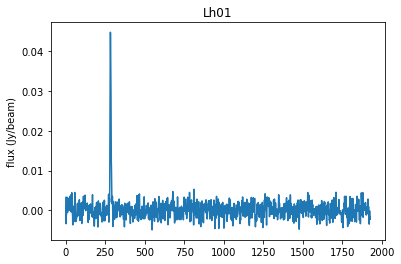

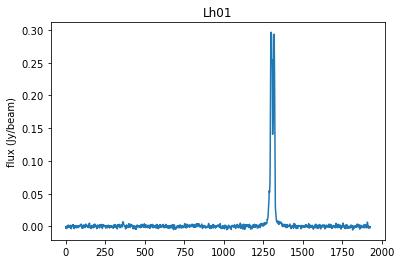

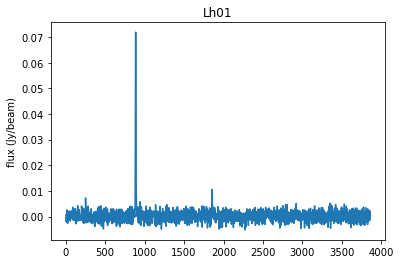

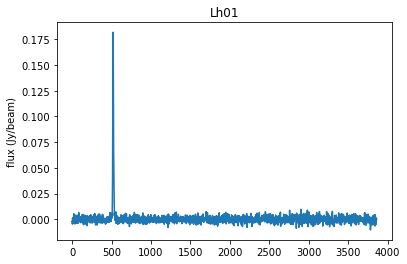

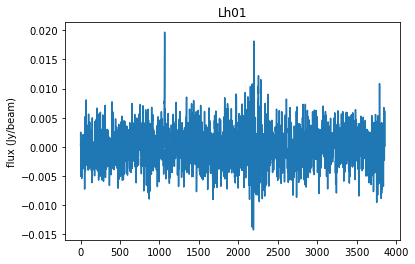

In [21]:
# 删掉识别不出的线和太密集的线
# 对齐速度
c=299792458


data_flux=[[] for _ in range(40)]
#plt.figure(figsize=(10,6))
for i in range(5):   #len(data)
    list_x=[]
    list_y=[]
    delta=[]
    raw_x,raw_y=data_to_xy(data[i])   # 一个spw文件的数据
    for j in range(len(raw_x)):    # 把视向速度扣掉
        list_x.append(raw_x[j]/(1-(V_rest_source[i]*10e3/c)))
        list_y.append(raw_y[j])
        if j<len(raw_x)-1:
            delta.append(raw_x[j+1]-raw_x[j])

    copied_list_x = copy.deepcopy(list_x)
    y_flux=duiqi_v(copied_list_x,list_y,max(delta),list_x[0],list_x[-1])
#     plt.plot(y_flux)
#     plt.show()
    
#     # 合并同一个源的光谱
#     note=0
    
    
    
    
#     this_x=list(range(0,len(y_flux)))
#     print(len(y_flux))
#     #print(len(this_x))
#     list_x_new,y_flux_new=hebin(this_x,y_flux)   # 合并
#     #print(len(y_flux_new))

#     y_flux_out_3sigma=remove_3sigma2(list_x_new,y_flux_new)  # 去除噪声

#     y_flux_out_3sigma_nol=guiyihua(y_flux_out_3sigma)  # 归一化

#     #plt.plot(list_x_new,y_flux_new,label=name[i][j]) 
#     #plt.plot(list_x_new,y_flux_new,this_x,y_flux,list_x_new,y_flux_out_3sigma,label=name[i][j]) # 原始数据vs合并且去噪声
#     plt.plot(list_x_new,y_flux_out_3sigma_nol,label=name[i][j])  # 归一化后的
#     #print(len(x_flux_out_3sigma))

# #         # 补齐长度(非常临时的方法！)
# #         if len(x_flux_out_3sigma)!=21:
# #             y_flux_out_3sigma.append(0)

#     data_flux.append(y_flux_out_3sigma_nol)

# #         print("长度：",len(y_flux_out_3sigma))
    plt.plot(y_flux)
    plt.title(name_list[i])
#     plt.xlim(list_x_new[0]-0.02,list_x_new[-1]+0.02)
#     ax = plt.gca()  # 获取当前轴
#     ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%0.2f'))

#     plt.xlabel("frequency (GHz)")
    plt.ylabel("flux (Jy/beam)")

    plt.show()

In [17]:
# 提取上能级温度
tem_data_usb=pd.read_excel(r'line_identification.xlsx',sheet_name=1,usecols=[0,2,7])
tem_data_lsb=pd.read_excel(r'line_identification.xlsx',sheet_name=2,usecols=[0,2,7])

# 遍历频率找到对应上能级温度
tem0=[]
for i in range(len(rest_fre0)):
    fre=rest_fre0[i]
    for j in range(len(tem_data_lsb)):
        if tem_data_lsb.values[j,1]==fre:
            tem0.append(tem_data_lsb.values[j,2])

tem1=[]
for i in range(len(rest_fre1)):
    fre=rest_fre1[i]
    for j in range(len(tem_data_lsb)):
        if tem_data_lsb.values[j,1]==fre:
            tem1.append(tem_data_lsb.values[j,2])

tem2=[]
for i in range(len(rest_fre2)):
    fre=rest_fre2[i]
    for j in range(len(tem_data_lsb)):
        if tem_data_lsb.values[j,1]==fre:
            tem2.append(tem_data_lsb.values[j,2])
            
tem3=[]
for i in range(len(rest_fre3)):
    fre=rest_fre3[i]
    for j in range(len(tem_data_usb)):
        if tem_data_usb.values[j,1]==fre:
            tem3.append(tem_data_usb.values[j,2])
            
tem4=[]
for i in range(len(rest_fre4)):
    fre=rest_fre4[i]
    for j in range(len(tem_data_usb)):
        if tem_data_usb.values[j,1]==fre:
            tem4.append(tem_data_usb.values[j,2])

tem=[tem0,tem1,tem2,tem3,tem4]
tem_all = np.concatenate(tem).tolist()
print(tem_all)

[24.7793, 71.9661, 70.9573, 150.6497, 434.6966, 56.2495, 151.0955, 105.0607, 126.4935, 76.4101, 16.5962, 98.5456, 62.1444, 151.5015, 127.818, 24.9808, 58.3478, 25.6816, 72.7122, 167.6567, 105.8234, 132.5369, 82.8004, 142.6542, 55.2022, 63.4714, 47.835, 41.402, 162.9316, 35.8865, 31.2935, 168.1381, 31.601, 27.0532, 101.6364, 196.9916]


In [115]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE,MDS, Isomap,LocallyLinearEmbedding,SpectralEmbedding
from sklearn.decomposition import PCA


In [117]:
#print(data_flux)
data_flux=y_flux_2
print(len(data_flux))


488


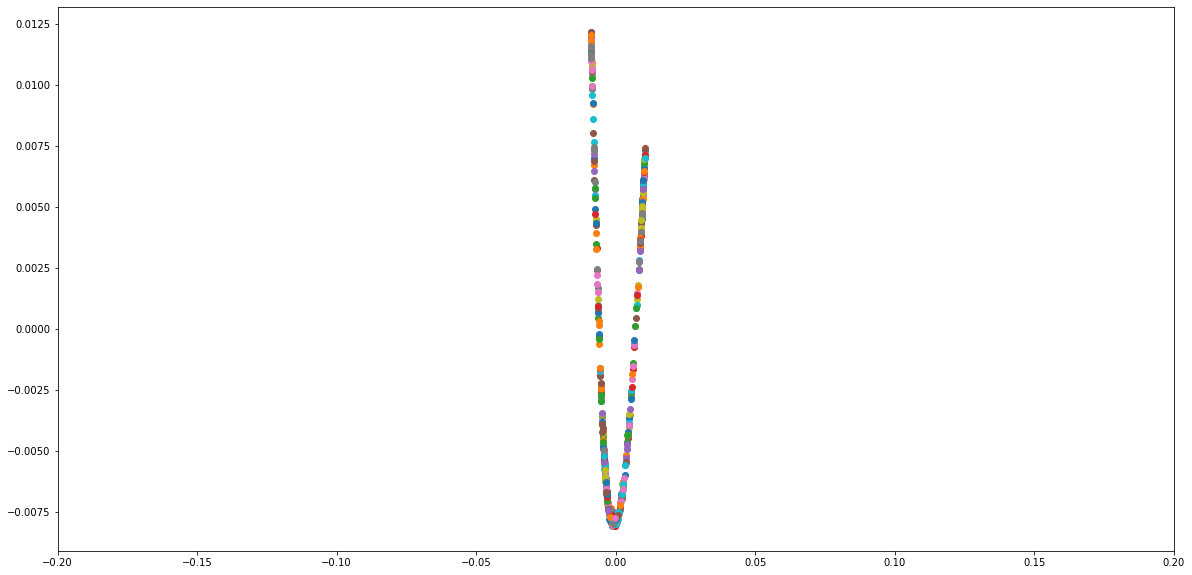

In [119]:

 
# tsne=TSNE(random_state=42)
# mds=MDS(n_components=2)
#iso=Isomap(n_components=2,n_neighbors=30)
#local=LocallyLinearEmbedding(n_components=2)
spec=SpectralEmbedding(n_components=2)
 
# digits_tsne=tsne.fit_transform(data_flux)
# digits_mds=mds.fit_transform(data_flux)
# digits_iso=iso.fit_transform(data_flux)
# digits_local=local.fit_transform(data_flux)
digits_spec=spec.fit_transform(data_flux)
# print(digits_tsne)
# colors=['#476A2A','#7851B8','#BD3430','#4A2D4E','#875525',
#         '#A83683','#4E655E','#853541','#3A3120','#535D8E']

color_map = {'33SO2':'#000000', '13CH3OH???':'#FF0000', 'CO':'#00FF00', 'HC15N':'#0000FF', 'CH3OH':'#FFFF00','H13CO+':'#00FFFF','SO+':'#FF00FF','SiO':'#FFA500', 'SO2':'#FFC0CB', 'HCO+':'#FFA07A', 'SO':'#A9A9A9', 'CH3OCH3':'#8B0000', '34SO2':'#ADD8E6', 't-HCOOH':'#90EE90', 'SO2_v2=1???':'#D8BFD8'}
 

# SpectralEmbedding
plt.figure(figsize=(20,10))
# plt.xlim(digits_spec[:,0].min(),digits_spec[:,0].max()+1)
# plt.ylim(digits_spec[:,1].min(),digits_spec[:,1].max()+1)
plt.xlim(-0.2,0.2)
for i in range(len(digits_spec)):
#     plt.text(digits_spec[i,0],digits_spec[i,1],str(new_name[i]),
#              color=colors[i],
#              fontdict={'weight':'bold','size':15})
    plt.scatter(digits_spec[i, 0], digits_spec[i, 1])
    
# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 0], digits_spec[:, 1], new_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))


plt.show()

(36, 47)


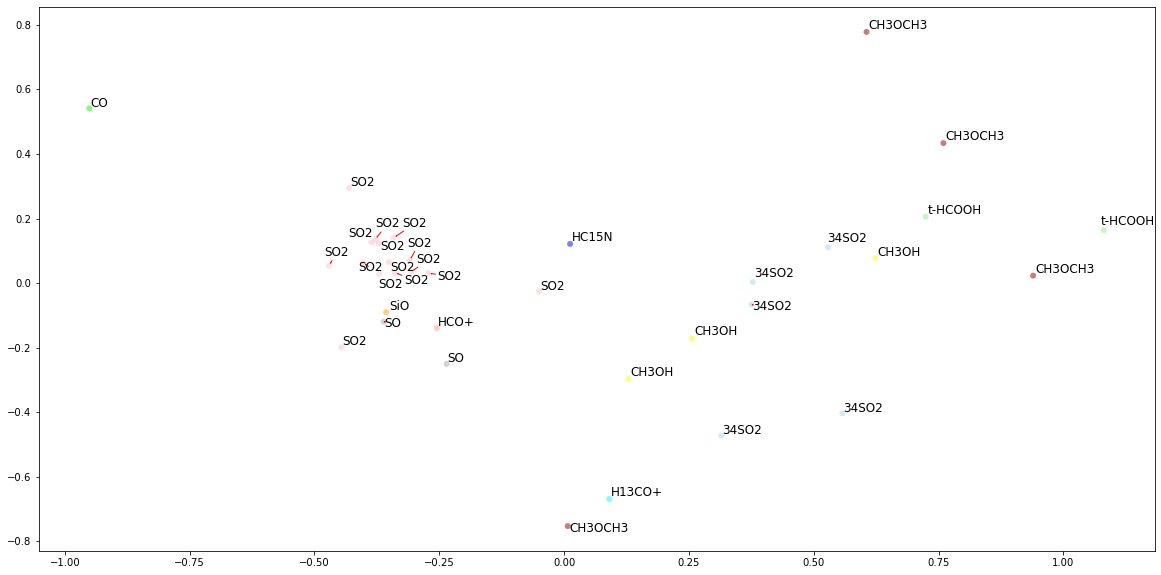

主成分（特征向量）：
 [[ 2.08166817e-17 -0.00000000e+00 -0.00000000e+00 -2.77555756e-17
   6.93889390e-18 -0.00000000e+00  1.69406589e-21 -1.32348898e-23
  -4.13590306e-25  1.61558713e-27  5.04870979e-29 -1.97215226e-31
  -6.43670810e-03 -1.80752175e-02 -2.72535960e-02 -5.36852710e-02
  -8.50373031e-02 -1.54629600e-01 -2.05655977e-01 -2.07141995e-01
  -1.52691974e-01 -2.48485048e-03  2.00520325e-02 -2.80791069e-01
  -5.11372679e-01 -4.43708754e-01 -3.73728201e-01 -2.87266714e-01
  -2.15376809e-01 -1.63807509e-01 -1.20634623e-01 -9.09827475e-02
  -2.16980058e-02 -7.54762586e-04 -0.00000000e+00 -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00 -0.00000000e+00]
 [ 5.55111512e-17 -1.11022302e-16  2.77555756e-17  2.77555756e-17
  -1.38777878e-17 -4.33680869e-19 -5.42101086e-20  0.00000000e+00
  -2.64697796e-23  0.00000000e+00  0.00000000e+00  0.00000000e+00
   9.92066960

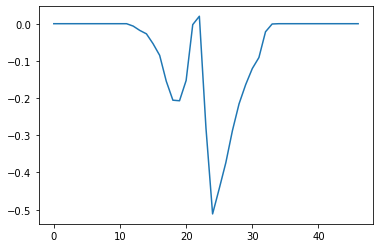

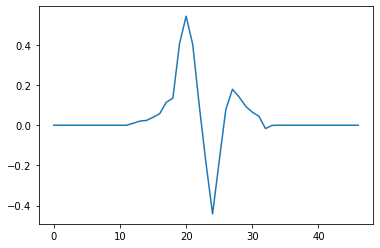

In [21]:
# PCA
data_flux=np.array(data_flux)
print(data_flux.shape)
model = PCA(2)  # project from 64 to 2 dimensions
model.fit(data_flux)
digits_pca = model.transform(data_flux)

plt.figure(figsize=(20,10))
for i in range(len(digits_pca)):
    plt.scatter(digits_pca[i, 0],digits_pca[i, 1], edgecolor='none', alpha=0.5,color=color_map[new_name[i]], label=new_name[i])
    
new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_pca[:, 0], digits_pca[:, 1], new_name)]
adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend()
plt.show()

# 5. 输出PCA的主成分和解释方差
print("主成分（特征向量）：\n", model.components_)
print("解释方差（每个主成分的贡献）：", model.explained_variance_ratio_)
com=model.components_
plt.plot(com[0])
plt.show()
plt.plot(com[1])
plt.show()

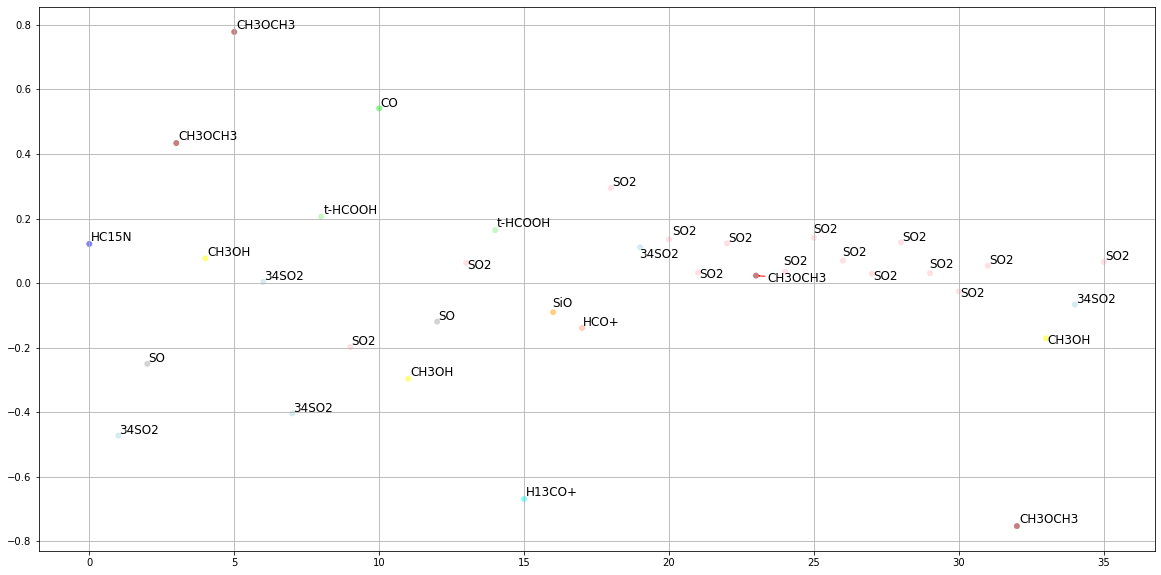

In [22]:
ax_pca=np.arange(0,36,1)
# x方向
plt.figure(figsize=(20,10))
for i in range(len(digits_pca)):
    plt.scatter(ax_pca[i],digits_pca[i, 1], edgecolor='none', alpha=0.5, color=color_map[new_name[i]],label=new_name[i])

new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(ax_pca, digits_pca[:, 1], new_name)]
adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
plt.grid()
plt.show()

In [23]:
# 求平均谱线
def mean_spec(list7):
    mean=[]
    for i in range(len(list7[0])):  # 数据长度
        mean_data=0
        for j in range(len(list7)):   # 有几组数据
            mean_data+=list7[j][i]
        mean.append(mean_data/len(list7))
    return mean

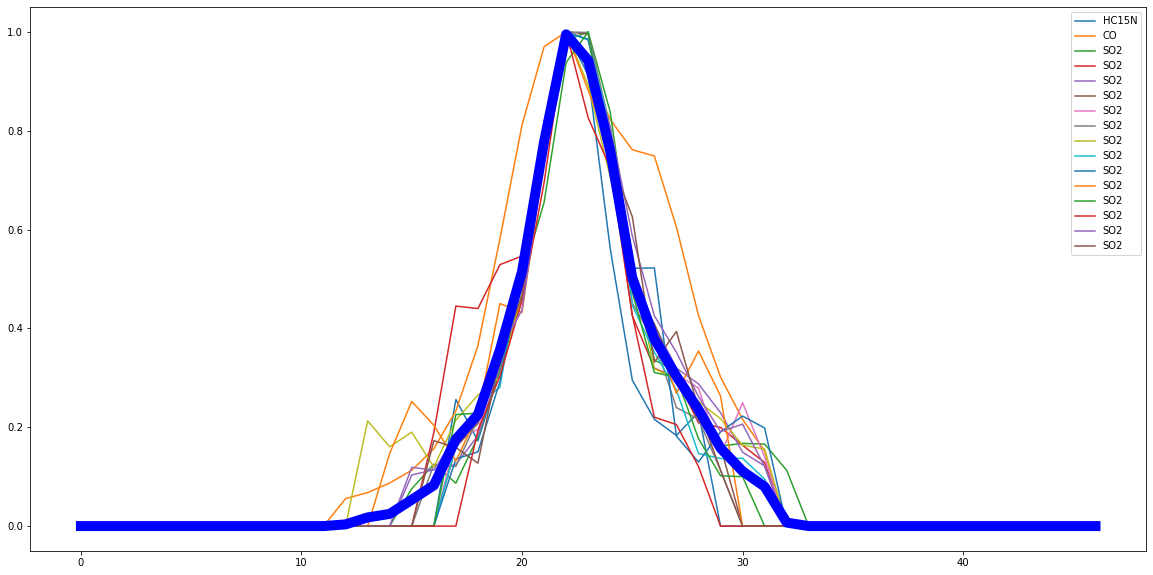

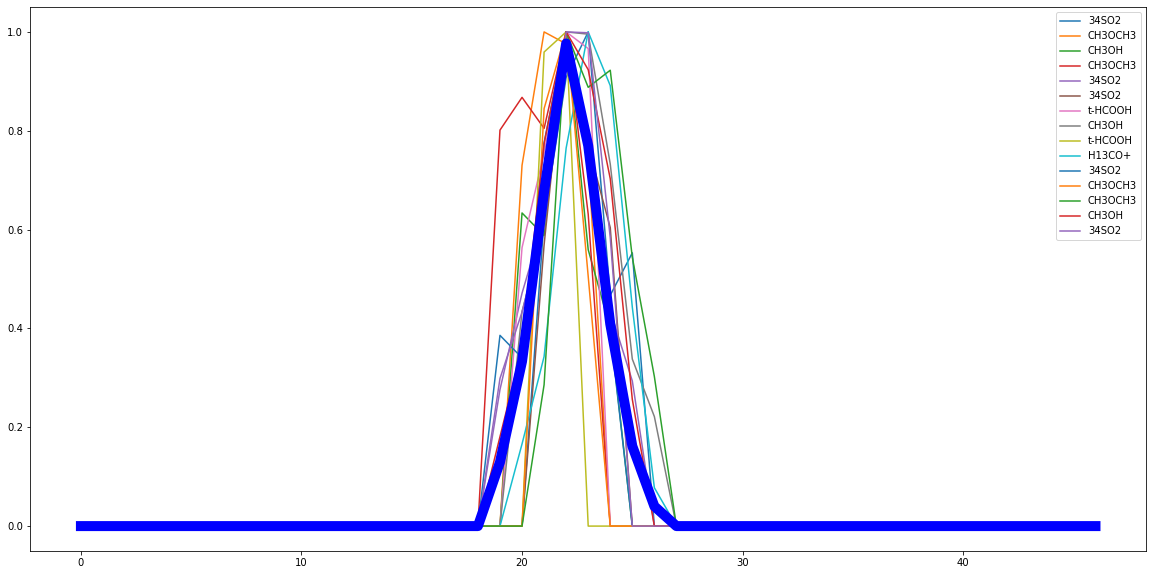

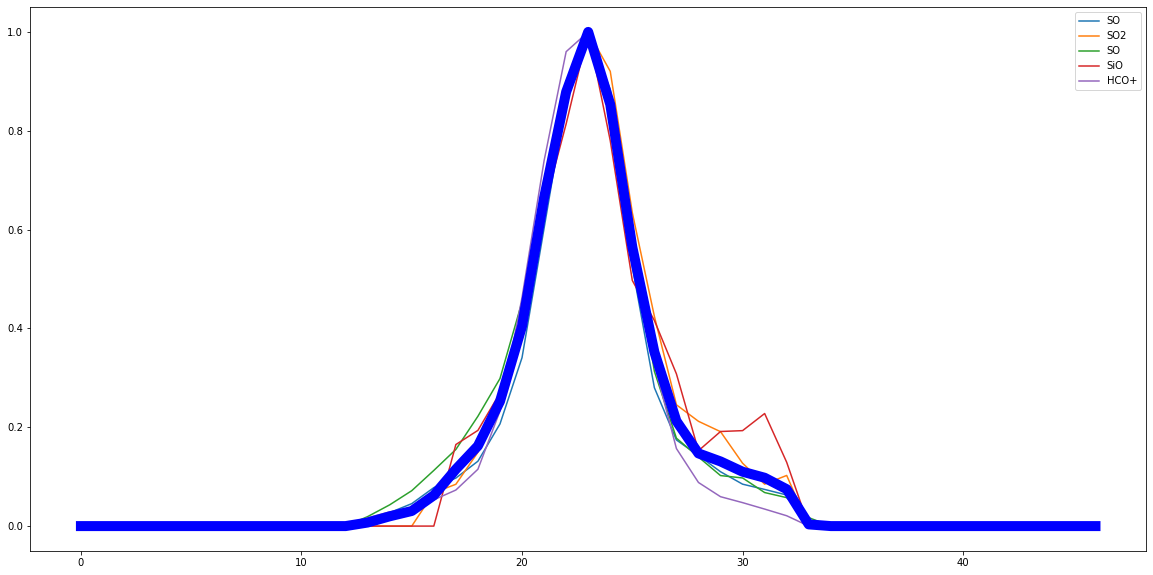

In [24]:
#print(digits_spec)
cate1=[]
name1=[]
mean1=[]
cate2=[]
name2=[]
mean2=[]
cate3=[]
name3=[]
mean3=[]
for i in range(len(digits_spec)):
    if digits_spec[i,0]>0 and digits_spec[i,1]<0.15:
        cate1.append(data_flux[i])
        name1.append(new_name[i])
        
    elif digits_spec[i,0]<0 and digits_spec[i,1]<0.15:
        cate2.append(data_flux[i])
        name2.append(new_name[i])
    elif digits_spec[i,0]<0.0 and digits_spec[i,1]>0.15:
        cate3.append(data_flux[i])
        name3.append(new_name[i])

# 求平均光谱
mean1=mean_spec(cate1)
mean2=mean_spec(cate2)
mean3=mean_spec(cate3)

# 画图
plt.figure(figsize=(20,10))
for i in range(len(cate1)):  
    plt.plot(cate1[i],label=name1[i])

plt.plot(mean1,linewidth=10,color="b")
#plt.ylim(-0.05,0.1)
plt.legend()
plt.show()

plt.figure(figsize=(20,10))
for i in range(len(cate2)):
    plt.plot(cate2[i],label=name2[i])

plt.plot(mean2,linewidth=10,color="b")
#plt.xlim(25,150)
plt.legend()
plt.show()

plt.figure(figsize=(20,10))
for i in range(len(cate3)):
    plt.plot(cate3[i],label=name3[i])

plt.plot(mean3,linewidth=10,color="b")
#plt.xlim(25,150)
plt.legend()
plt.show()

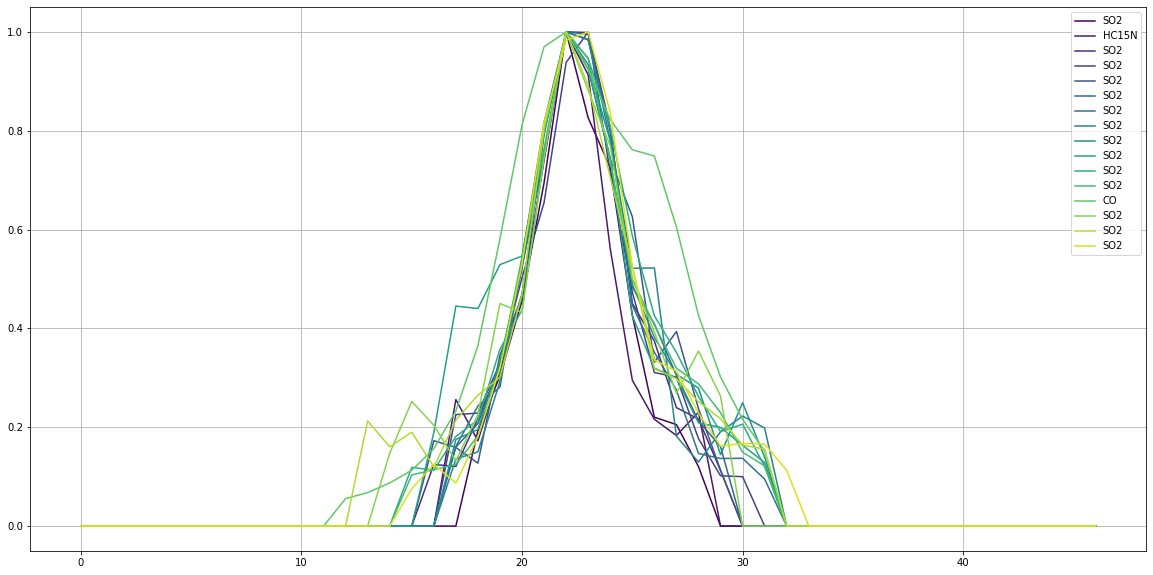

In [25]:
# 把SO2的x增大顺序画出来
sort_x_so2=[]    # 按顺序排列的x值
cate1_x_so2=[]  # x值
digits_so2_x=[]  # 谱线流量
name_so2_x=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
    if digits_spec[i,0]>0 and digits_spec[i,1]<0.15:
        digits_so2_x.append(digits_spec[i,0])
        cate1_x_so2.append(data_flux[i])
        name_so2_x.append(new_name[i])
        
linewidth_x=[]
x_so2=zip(digits_so2_x,cate1_x_so2,name_so2_x)
sorted_x_so2 = sorted(x_so2,key=lambda x:x[0])
result = zip(*sorted_x_so2)
sorted_so2_x, sorted_so2_flux,sorted_so2_name = [list(x) for x in result]

cmap = plt.cm.viridis
plt.figure(figsize=(20,10))

for i in range(len(sorted_so2_flux)):   # 算一下线宽（最底部）
    #print(sorted_so2_x[i])
    a=0
    b=0
    for j in range(len(sorted_so2_flux[i])-1):
        if sorted_so2_flux[i][j]==0 and sorted_so2_flux[i][j+1]>0:
            a=j
        if sorted_so2_flux[i][j]==0 and sorted_so2_flux[i][j-1]>0:
            b=j
    
    #print("线宽：",b-a)
    linewidth_x.append(b-a)
    
    color = cmap(i / len(sorted_so2_flux))
    plt.plot(sorted_so2_flux[i],color=color,label=sorted_so2_name[i])
    #plt.title("x value:{}".format(sorted_so2_x[i]))
    #plt.title("name:{}".format(sorted_so2_name[i]))
    #plt.savefig('./picture/sorted_x-{}.png'.format(i + 1))


plt.legend(loc="upper right")
plt.grid()
plt.show()

#print(linewidth_x)

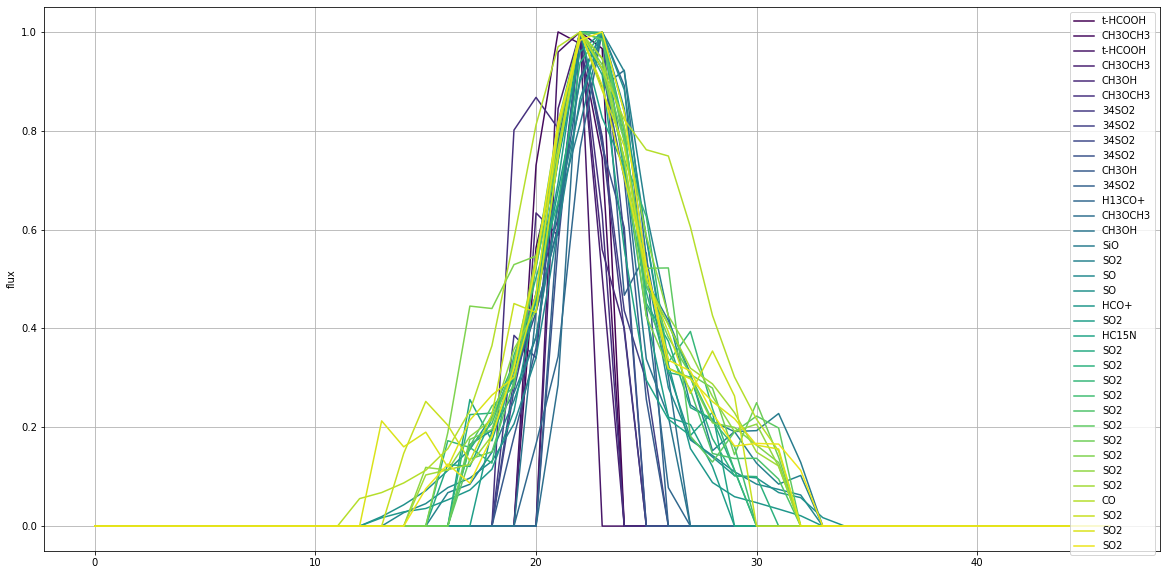

In [26]:
# 把所有谱线按的x增大顺序画出来
sort_x=[]    # 按x顺序排列的下面三个列表的组合
cate1_x=[]  # 谱线流量
digits_x=[]  # 分类结果中该谱线的x值
name_x=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
    digits_x.append(digits_spec[i,0])
    cate1_x.append(data_flux[i])
    name_x.append(new_name[i])
        
linewidth_x_all=[]
x_=zip(digits_x,cate1_x,name_x)
sort_x = sorted(x_,key=lambda x:x[0])
result = zip(*sort_x)
sorted_x, sorted_flux,sorted_name = [list(x) for x in result]

cmap = plt.cm.viridis
plt.figure(figsize=(20,10))

for i in range(len(sorted_flux)):   # 算一下线宽（最底部）
    #print(sorted_so2_x[i])
    a=0
    b=0
    for j in range(len(sorted_flux[i])-1):
        if sorted_flux[i][j]==0 and sorted_flux[i][j+1]>0:
            a=j
        if sorted_flux[i][j]==0 and sorted_flux[i][j-1]>0:
            b=j
    
    #print("线宽：",b-a)
    linewidth_x_all.append(b-a)
    
    color = cmap(i / len(sorted_flux))
    plt.plot(sorted_flux[i],color=color,label=sorted_name[i])
    #plt.title("x value:{}".format(sorted_so2_x[i]))
    #plt.title("name:{}".format(sorted_so2_name[i]))
    #plt.savefig('./picture/sorted_x-{}.png'.format(i + 1))


plt.legend(loc="upper right")
plt.ylabel("flux")
plt.grid()
plt.show()

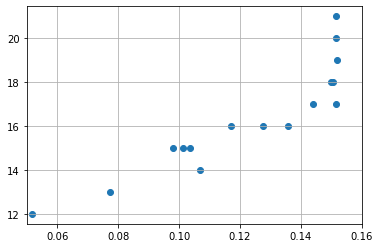

In [27]:
# 画出x值和线宽的散点图
sorted_so2_x = np.array(sorted_so2_x)
linewidth_x = np.array(linewidth_x)
plt.scatter(sorted_so2_x,linewidth_x)
plt.xlim(0.05,0.16)
plt.grid()
plt.show()

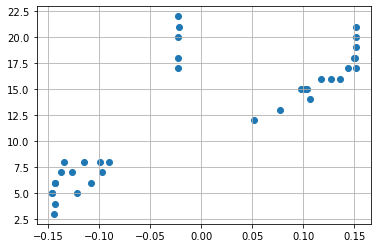

In [28]:
# 画出所有谱线x值和线宽的散点图
sorted_x = np.array(sorted_x)
linewidth_x_all = np.array(linewidth_x_all)
plt.scatter(sorted_x,linewidth_x_all)
#plt.xlim(0.05,0.16)
plt.grid()
plt.show()

In [29]:
# 把SO2的y增大顺序画出来
sort_y_so2=[]
cate1_y_so2=[]
digits_so2_y=[]

for i in range(len(digits_spec)):
    if digits_spec[i,0]>0 and digits_spec[i,1]<0.15:
        digits_so2_y.append(digits_spec[i,1])
        cate1_y_so2.append(data_flux[i])
        
linewidth_y=[]
y_so2=zip(digits_so2_y,cate1_y_so2)
sorted_y_so2 = sorted(y_so2,key=lambda x:x[0])
result = zip(*sorted_y_so2)
sorted_so2_y, sorted_so2_flux = [list(x) for x in result]

for i in range(len(sorted_so2_flux)):   # 算一下线宽（最底部）
    print(sorted_so2_y[i])
    a=0
    b=0
    for j in range(len(sorted_so2_flux[i])-1):
        if sorted_so2_flux[i][j]==0 and sorted_so2_flux[i][j+1]>0:
            a=j
        if sorted_so2_flux[i][j]==0 and sorted_so2_flux[i][j-1]>0:
            b=j
    linewidth_y.append(b-a)
    print("线宽：",b-a)
#     plt.plot(sorted_so2_flux[i])
#     plt.title("y value:{}".format(sorted_so2_y[i]))
#     plt.savefig('./picture/sorted_y-{}.png'.format(i + 1))
#     plt.show()
print(linewidth_y)

-0.10295652931425181
线宽： 19
-0.10250386678181798
线宽： 21
-0.10250386678181794
线宽： 20
-0.10250386678181786
线宽： 17
-0.09926937037413046
线宽： 18
-0.09667348809249963
线宽： 18
-0.07791596838945215
线宽： 17
-0.0522679913437954
线宽： 16
-0.0270401583472192
线宽： 16
0.0005789567123304899
线宽： 16
0.027958887762676618
线宽： 14
0.03684363076079418
线宽： 15
0.03695772879455899
线宽： 15
0.0426882326806361
线宽： 15
0.07710567738732602
线宽： 13
0.11054892432629239
线宽： 12
[19, 21, 20, 17, 18, 18, 17, 16, 16, 16, 14, 15, 15, 15, 13, 12]


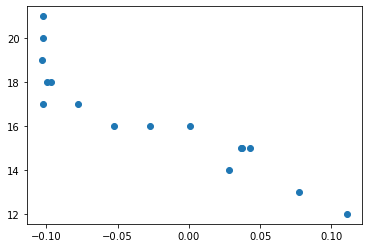

In [30]:
# 画出y值和线宽的散点图
plt.scatter(sorted_so2_y,linewidth_y)

plt.show()

In [31]:
# 计算半高全宽
def calculate_fwhm(x, y, n): # n是取多少高
    # 确保x和y为NumPy数组
    x = np.asarray(x)
    y = np.asarray(y)
    
    # 找到峰值位置
    peak_index = np.argmax(y)
    peak_value = y[peak_index]
    half_max = peak_value*n

    # 处理左侧交点
    i_left = peak_index - 1
    while i_left >= 0 and y[i_left] > half_max:
        i_left -= 1
    
    if i_left < 0:
        raise ValueError("未找到左侧半高交点，请检查数据。")
    if i_left + 1 >= len(y):
        raise ValueError("左侧交点超出范围。")
    
    # 线性插值计算左侧交点x坐标
    dx_left = x[i_left + 1] - x[i_left]
    dy_left = y[i_left + 1] - y[i_left]
    x_left = x[i_left] + (half_max - y[i_left]) * dx_left / dy_left

    # 处理右侧交点
    i_right = peak_index + 1
    while i_right < len(y) and y[i_right] >= half_max:
        i_right += 1
    
    if i_right >= len(y):
        raise ValueError("未找到右侧半高交点，请检查数据。")
    if i_right - 1 < peak_index:
        raise ValueError("右侧交点无效。")
    
    # 线性插值计算右侧交点x坐标
    dx_right = x[i_right] - x[i_right - 1]
    dy_right = y[i_right] - y[i_right - 1]
    x_right = x[i_right - 1] + (half_max - y[i_right - 1]) * dx_right / dy_right
    return x_right - x_left

In [32]:
# 底线宽
def linewidth(y):
    a=0
    b=0
    for i in range(len(y)-1):
        if y[i]==0 and y[i+1]>0:
            a=i
        if y[i]==0 and y[i-1]>0:
            b=i
    
    #print("线宽：",b-a)
    return (b-a)

In [33]:
def simpson_integral(x, y):
    # 检查数据均匀间隔
    h = x[1] - x[0]
    for i in range(1, len(x)):
        if not np.isclose(x[i] - x[i-1], h):
            raise ValueError("数据点必须均匀间隔！")
    
    # 检查偶数个区间（数据点数为奇数）
    n = len(x) - 1  # 区间数
    if n % 2 != 0:
        raise ValueError("区间数需为偶数（数据点数需为奇数）")
    
    # 辛普森公式计算
    integral = y[0] + y[-1]
    for i in range(1, n):
        if i % 2 == 0:
            integral += 2 * y[i]
        else:
            integral += 4 * y[i]
    integral *= h / 3
    return integral

In [34]:
# 面积
def area(x,y):
    a=np.trapz(y, x)
    return a

In [35]:
# 面积比值
def a_ratio(x,y,n):
# 找到对应高度的横坐标
    # 确保x和y为NumPy数组
    x = np.asarray(x)
    y = np.asarray(y)
    
    # 找到峰值位置
    peak_index = np.argmax(y)
    peak_value = y[peak_index]
    half_max = peak_value*n

    # 处理左侧交点
    i_left = peak_index - 1
    while i_left >= 0 and y[i_left] > half_max:
        i_left -= 1
    
    if i_left < 0:
        raise ValueError("未找到左侧半高交点，请检查数据。")
    if i_left + 1 >= len(y):
        raise ValueError("左侧交点超出范围。")
    
    # 线性插值计算左侧交点x坐标
    dx_left = x[i_left + 1] - x[i_left]
    dy_left = y[i_left + 1] - y[i_left]
    x_left = x[i_left] + (half_max - y[i_left]) * dx_left / dy_left

    # 处理右侧交点
    i_right = peak_index + 1
    while i_right < len(y) and y[i_right] >= half_max:
        i_right += 1
    
    if i_right >= len(y):
        raise ValueError("未找到右侧半高交点，请检查数据。")
    if i_right - 1 < peak_index:
        raise ValueError("右侧交点无效。")
    
    # 线性插值计算右侧交点x坐标
    dx_right = x[i_right] - x[i_right - 1]
    dy_right = y[i_right] - y[i_right - 1]
    x_right = x[i_right - 1] + (half_max - y[i_right - 1]) * dx_right / dy_right
    
# 计算面积
    x_left_int=int(x_left)
    x_right_int=int(x_right)
    left=np.arange(0,x_left_int+1)
    right=np.arange(x_right_int+1,x[-1]+1)
    area_left=np.trapz( y[0:x_left_int+1],left)
    area_right=np.trapz(y[x_right_int+1:x[-1]+1],right)
    area_middle=(x_right-x_left)*half_max
    return area_left+area_right

In [36]:
def tr(a):
    a+=1
    return a
aaa=1
print(tr(aaa))
print(aaa)

2
1


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]


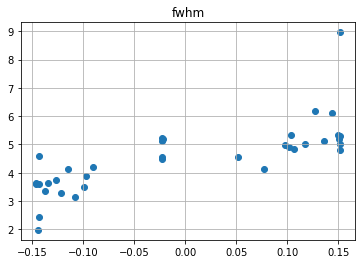

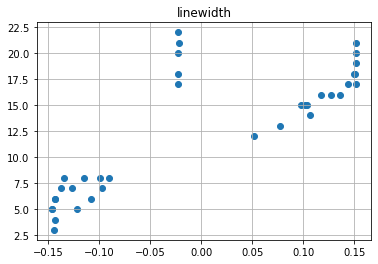

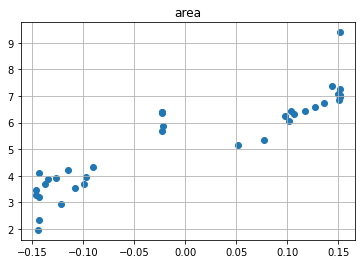

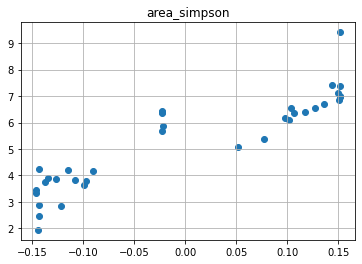

In [37]:
fwhm_full=[]
linewidth_full=[]
area_full=[]
area_full2=[]
flux_x = np.arange(0, len(sorted_flux[1]),1)
print(flux_x)
for i in range(len(sorted_x)):
    fwhm=calculate_fwhm(flux_x,sorted_flux[i],0.5)
    fwhm_full.append(fwhm)
    linewid=linewidth(sorted_flux[i])
    linewidth_full.append(linewid)
    area_full.append(area(flux_x,sorted_flux[i]))
    area2 = simpson_integral(flux_x,sorted_flux[i])
    area_full2.append(area2)

# 画出所有谱线x值和不同属性的散点图
plt.scatter(sorted_x,fwhm_full)
#plt.xlim(0.05,0.16)
plt.title("fwhm")
plt.grid()
plt.show()

plt.scatter(sorted_x,linewidth_full)
#plt.xlim(0.05,0.16)
plt.title("linewidth")
plt.grid()
plt.show()

plt.scatter(sorted_x,area_full)
#plt.xlim(0.05,0.16)
plt.title("area")
plt.grid()
plt.show()

plt.scatter(sorted_x,area_full2)
#plt.xlim(0.05,0.16)
plt.title("area_simpson")
plt.grid()
plt.show()

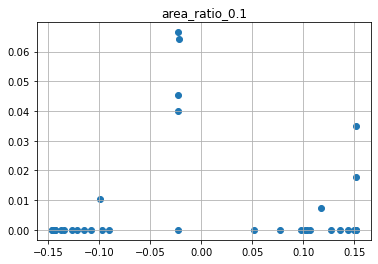

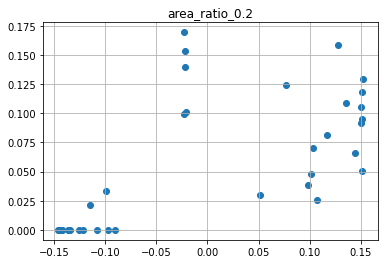

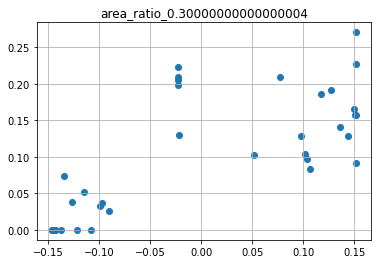

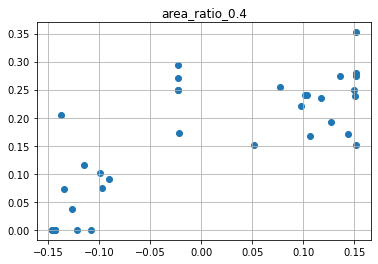

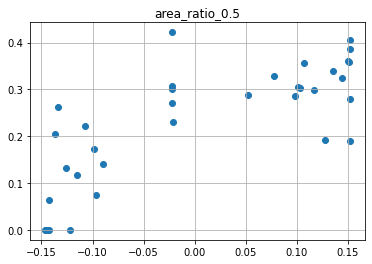

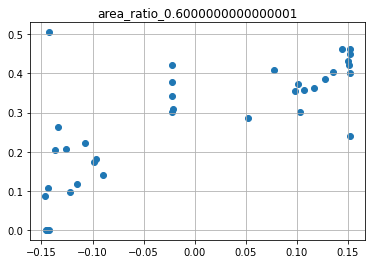

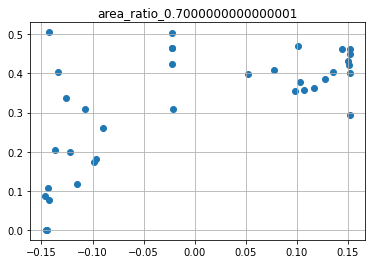

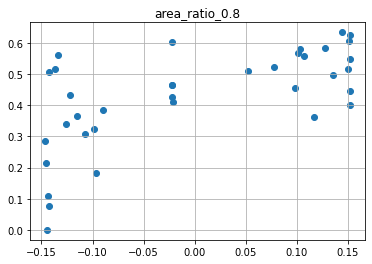

In [38]:

flux_x = np.arange(0, len(sorted_flux[1]),1)
for n in range(1,9):
    area_full=[]
    area_ratio=[]
    for i in range(len(sorted_x)):
        area_full.append(area(flux_x,sorted_flux[i]))
        area_ratio.append(a_ratio(flux_x,sorted_flux[i],n*0.1)/area(flux_x,sorted_flux[i]))
    plt.scatter(sorted_x,area_ratio)
    #plt.xlim(0.05,0.16)
    plt.title("area_ratio_{}".format(n*0.1))
    plt.grid()
    plt.show()

In [39]:
# 均方根
def ruggedness_rms(y):
    dy = np.diff(y)
    return np.sqrt(np.mean(dy**2))

In [40]:
# 信息熵
def ruggedness_entropy(y):
    y_normalized = y / np.sum(y)
    entropy = -np.sum(y_normalized * np.log2(y_normalized + 1e-10))  # 避免log(0)
    return entropy

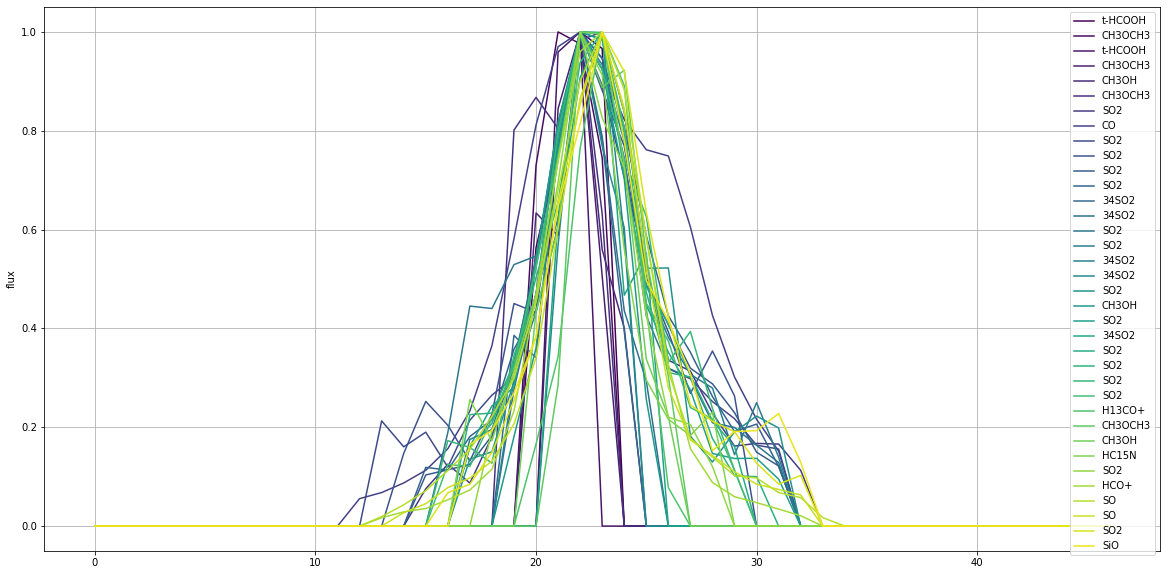

In [41]:
# 把所有谱线按y的增大顺序画出来
sort_y=[]    # 按顺序排列的y值
cate1_y=[]  # x值
digits_y=[]  # 谱线流量
name_y=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
    digits_y.append(digits_spec[i,1])
    cate1_y.append(data_flux[i])
    name_y.append(new_name[i])
        
y_=zip(digits_y,cate1_y,name_y)
sort_y = sorted(y_,key=lambda x:x[0])
result = zip(*sort_y)
sorted_y, sorted_flux_y,sorted_name_y = [list(x) for x in result]

cmap = plt.cm.viridis
plt.figure(figsize=(20,10))

rms_y=[]
entropy_y=[]
linewidth_y=[]
fwhm_y=[]
area_y=[]

for i in range(len(sorted_flux_y)):
    color = cmap(i / len(sorted_flux_y))
    plt.plot(sorted_flux_y[i],color=color,label=sorted_name_y[i])
    rms_y.append(ruggedness_rms(sorted_flux_y[i]))
    entropy_y.append(ruggedness_entropy(sorted_flux_y[i]))
    linewidth_y.append(linewidth(sorted_flux_y[i]))
    fwhm_y.append(calculate_fwhm(flux_x,sorted_flux_y[i],0.5))
    area_y.append(area(flux_x,sorted_flux_y[i]))

plt.legend(loc="upper right")
plt.ylabel("flux")
plt.grid()
plt.show()

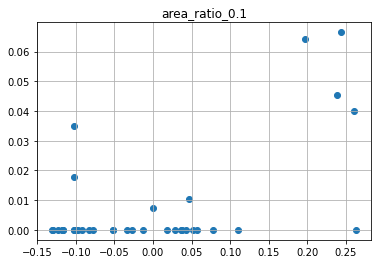

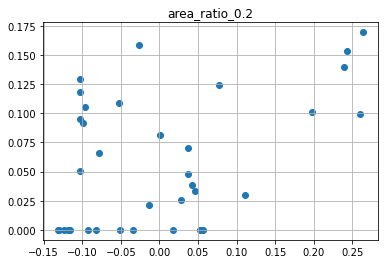

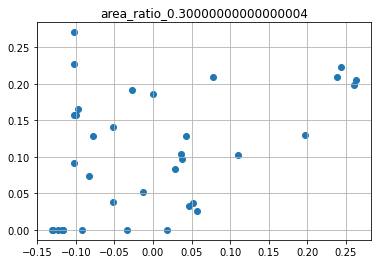

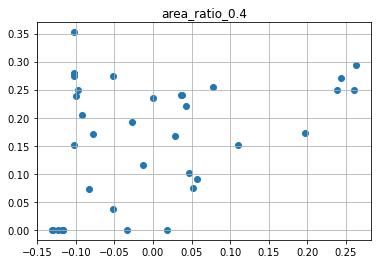

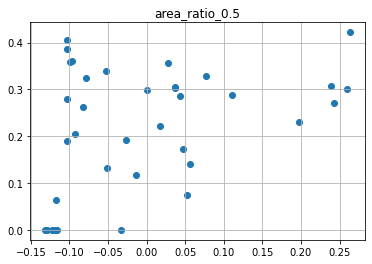

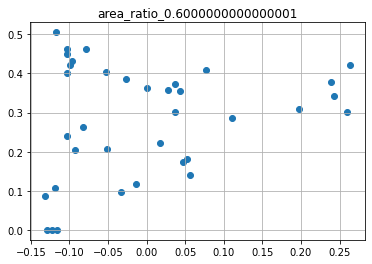

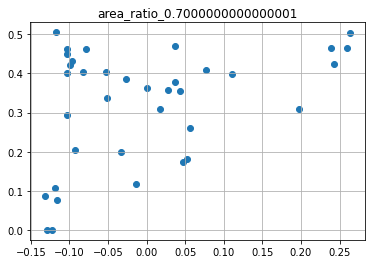

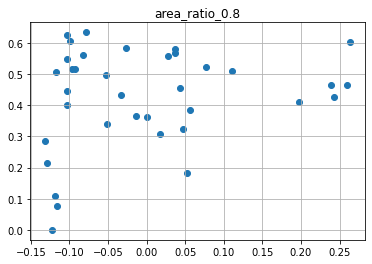

In [42]:
flux_x = np.arange(0, len(sorted_flux_y[1]),1)
for n in range(1,9):
    area_full_y=[]
    area_ratio_y=[]
    for i in range(len(sorted_y)):
        area_full_y.append(area(flux_x,sorted_flux_y[i]))
        area_ratio_y.append(a_ratio(flux_x,sorted_flux_y[i],n*0.1)/area(flux_x,sorted_flux_y[i]))
    plt.scatter(sorted_y,area_ratio_y)
    #plt.xlim(0.05,0.16)
    plt.title("area_ratio_{}".format(n*0.1))
    plt.grid()
    plt.show()

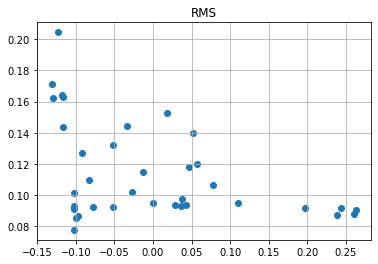

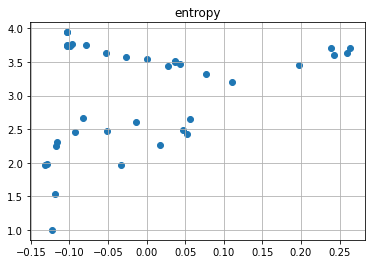

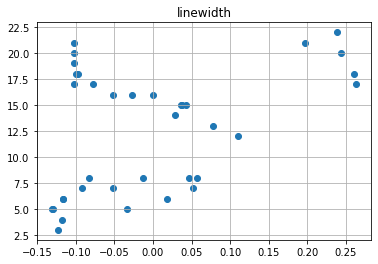

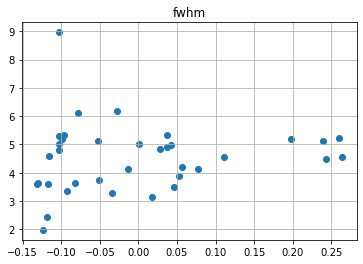

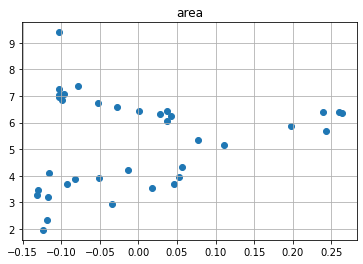

In [43]:
# 画出所有谱线y值和不同属性的散点图
plt.scatter(sorted_y,rms_y)
#plt.xlim(0.05,0.16)
plt.title("RMS")
plt.grid()
plt.show()

plt.scatter(sorted_y,entropy_y)
#plt.xlim(0.05,0.16)
plt.title("entropy")
plt.grid()
plt.show()

plt.scatter(sorted_y,linewidth_y)
#plt.xlim(0.05,0.16)
plt.title("linewidth")
plt.grid()
plt.show()

plt.scatter(sorted_y,fwhm_y)
#plt.xlim(0.05,0.16)
plt.title("fwhm")
plt.grid()
plt.show()

plt.scatter(sorted_y,area_y)
#plt.xlim(0.05,0.16)
plt.title("area")
plt.grid()
plt.show()

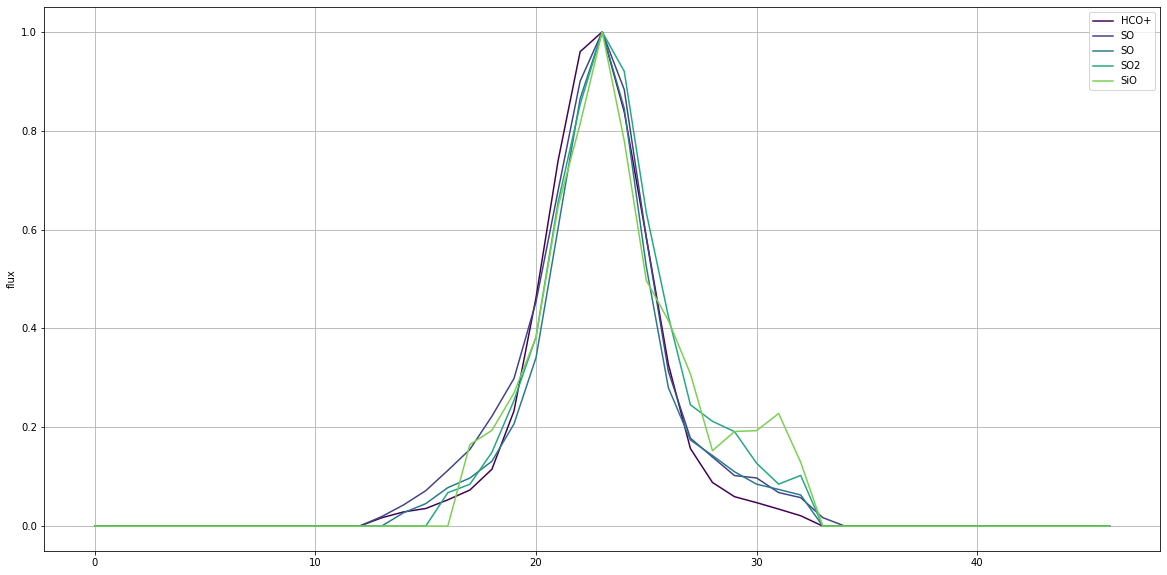

[0.19718835966940468, 0.23868247544660212, 0.24321204828855933, 0.25984216598361326, 0.26316346799936385]


In [44]:
# 把下半部分谱线按y的增大顺序画出来
sort_y_down=[]    # 按顺序排列的x值
cate1_y_down=[]  # x值
digits_y_down=[]  # 谱线流量
name_y_down=[]    # 记录谱线的名字

for i in range(len(digits_spec)):
    if digits_spec[i,1]>0.15 :
        digits_y_down.append(digits_spec[i,1])
        cate1_y_down.append(data_flux[i])
        name_y_down.append(new_name[i])
        
y_down_=zip(digits_y_down,cate1_y_down,name_y_down)
sort_y_down = sorted(y_down_,key=lambda x:x[0])
result = zip(*sort_y_down)
sorted_y_down, sorted_flux_y_down,sorted_name_y_down = [list(x) for x in result]

cmap = plt.cm.viridis
plt.figure(figsize=(20,10))


for i in range(len(sorted_flux_y_down)):
    color = cmap(i / len(sorted_flux_y_down))
    plt.plot(sorted_flux_y_down[i],color=color,label=sorted_name_y_down[i])


plt.legend(loc="upper right")
plt.ylabel("flux")
plt.grid()
plt.show()
print(sorted_y_down)